# Beta Functions

The Beta function is a special function defined by the integral

$$
\mathrm{B}(a,b) = \int_0^1 t^{a-1}(1-t)^{b-1}\,dt,
$$

for $a>0$ and $b>0$. It is closely related to the Gamma function through

$$
\mathrm{B}(a,b) = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a+b)}.
$$

SciPy provides several functions related to the Beta function, including the Beta function itself, its logarithm, and the regularized incomplete Beta functions.

In [1]:
from scipy import special
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

In [3]:
def plot_beta(type="beta", a=2, b=1, x_min=0, x_max=1, num=1000):
    x = np.linspace(x_min, x_max, num)
    if type == "beta":
        vals = special.beta(a, x)
        ylabel = r"$\mathrm{B}({a}, x)$"
    elif type == "betaln":
        vals = special.betaln(a, x)
        ylabel = r"$\ln \mathrm{B}({a}, x)$"
    elif type == "betainc":
        vals = special.betainc(a, b, x)
        ylabel = r"$I_x({a}, {b}, x)$"
    elif type == "betaincc":
        vals = special.betaincc(a, b, x)
        ylabel = r"$\bar{I}_x({a}, {b}, x)$"
    else:
        raise ValueError("Type is not recognized.")
    plt.figure(figsize=(5, 5))
    plt.plot(x, vals, "r")
    plt.xlabel(r"$x$")
    plt.ylabel(ylabel.replace("{a}", f"{str(a)}").replace("{b}", f"{str(b)}"))
    plt.tight_layout()
    plt.show()

## Beta Function

The Beta function can be evaluated using `special.beta`. For example,

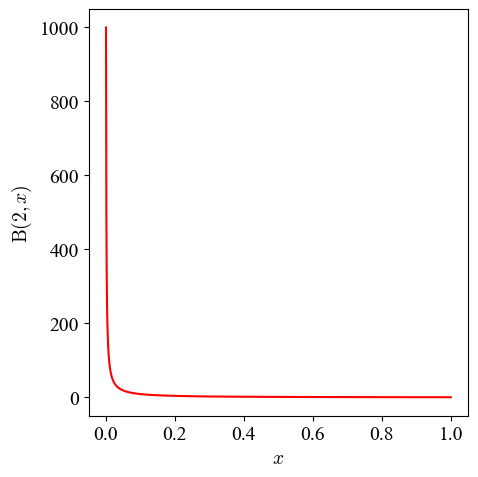

In [4]:
plot_beta(type="beta")

Here, $a=2$ is fixed while the second parameter varies with $x$. The resulting curve therefore represents

$$
\mathrm{B}(2,x).
$$

The Beta function is symmetric in its two arguments:

$$
\mathrm{B}(a,b) = \mathrm{B}(b,a).
$$

## Logarithm of the Beta Function

For large parameter values, the Beta function can become extremely small. Its logarithm is therefore often more convenient numerically. SciPy provides the logarithm of the Beta function through `special.betaln(a, x)` which corresponds to

$$
\ln\mathrm{B}(a,x).
$$

It can be visualized using

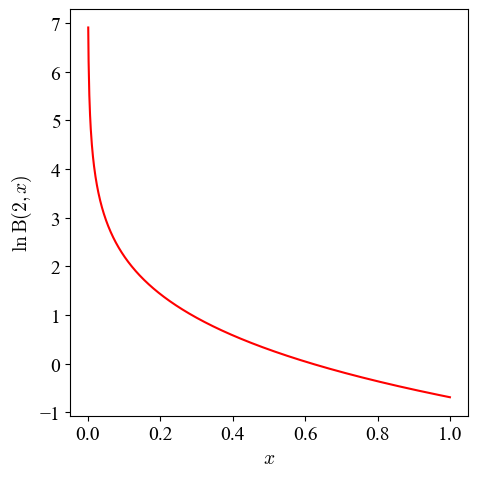

In [5]:
plot_beta(type="betaln")

Working with the logarithm is useful when evaluating products and ratios of Gamma or Beta functions that may otherwise suffer from numerical overflow or underflow.

## Regularized Incomplete Beta Function

The incomplete Beta function is defined by

$$
\mathrm{B}_x(a,b) = \int_0^x t^{a-1}(1-t)^{b-1}\,dt.
$$

Its regularized form is

$$
I_x(a,b) = \frac{\mathrm{B}_x(a,b)}{\mathrm{B}(a,b)}.
$$

SciPy provides the regularized incomplete Beta function using `special.betainc(a, b, x)`. For example,

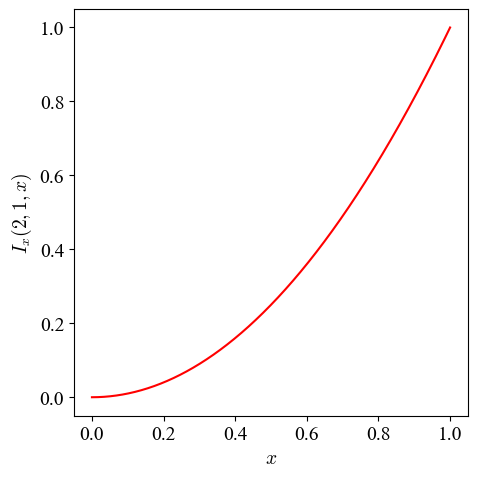

In [6]:
plot_beta(type="betainc")

Since the incomplete integral is normalized by the complete Beta function,

$$
I_0(a,b) = 0,\quad
I_1(a,b) = 1.
$$

Thus, the function varies between $0$ and $1$ for $0\leq x\leq1$.

## Complementary Regularized Incomplete Beta Function

The complementary regularized incomplete Beta function is

$$
\bar I_x(a,b) = 1 - I_x(a,b).
$$

It can be evaluated using `special.betaincc(a, b, x)` and plotted using

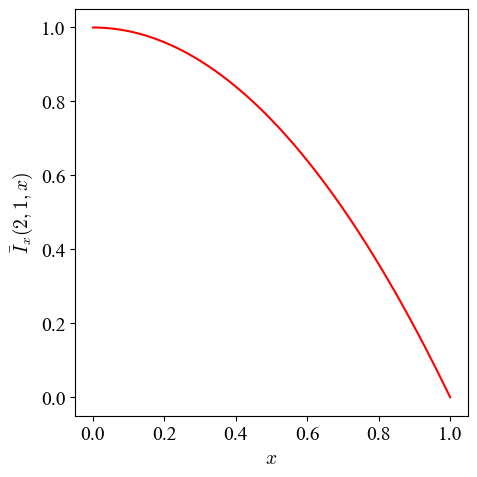

In [7]:
plot_beta(type="betaincc")

The two regularized functions satisfy

$$
I_x(a,b) + \bar I_x(a,b) = 1.
$$

Therefore, while `betainc` measures the accumulated contribution from $0$ to $x$, `betaincc` gives the remaining contribution from $x$ to $1$.